#  Diabetes Pre-Screening Tool
## Problem Statement

Diabetes is one of the fastest-growing chronic diseases globally, yet a large proportion of cases go undetected until complications arise. Clinical diagnosis relies on fasting glucose tests, HbA1c measurements, and oral glucose tolerance tests — all of which require lab infrastructure, trained personnel, and significant cost. In low-resource settings or primary care contexts, this creates a critical gap between risk and diagnosis.

**This project builds a low-cost pre-screening classifier** that uses easily collectable patient attributes — age, BMI, number of pregnancies, blood pressure, and basic glucose readings — to flag individuals at elevated diabetes risk *before* formal testing. The goal is not to replace clinical diagnosis, but to prioritise who needs it most.

**Target population:** Adult women from the Pima Indian heritage cohort (NIDDK dataset). While this is a specific demographic, the modelling methodology transfers to broader screening contexts.

**Deployment framing:** The tool is designed to run as a decision-support layer in primary health camps, tele-health platforms, or insurance intake workflows where full diagnostic testing is unavailable or cost-prohibitive.

### Why recall is the north star metric

In a pre-screening context, the cost of a **false negative** (missing a diabetic patient) is far higher than the cost of a **false positive** (flagging a non-diabetic for follow-up). A false negative means a patient with diabetes walks away without intervention. A false positive means an extra confirmatory test — inconvenient, but not dangerous.

This asymmetry drives every modelling decision in this notebook: class weighting, metric selection (F2 score over F1), threshold optimisation, and final model comparison all prioritise recall for the positive (diabetic) class.


## Setup & Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import warnings

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, make_scorer, fbeta_score
from sklearn.model_selection import cross_val_score

warnings.filterwarnings("ignore")

## Data Loading & Initial Inspection

The dataset contains **768 records** of Pima Indian women (age ≥ 21), with 8 clinical/demographic features and a binary outcome (1 = diabetic, 0 = non-diabetic). All features are numeric and represent either measurements or counts that could plausibly be collected at low cost in a primary care setting.


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/diabetes.csv')

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Data Cleaning & Imputation

### Identifying Impossible Zeros

`df.describe()` reveals zero values in columns where a biological zero is impossible: Glucose, BloodPressure, SkinThickness, Insulin, and BMI. A person with 0 blood pressure or 0 BMI is not alive — these are clearly missing values encoded as zeros, a common artifact in older medical datasets.

**Pregnancies** is intentionally excluded: zero pregnancies is a valid, common value.

The cell below isolates rows where BloodPressure == 0 to verify the pattern before replacing.


In [7]:
df[df["BloodPressure"]==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
7,10,115,0,0,0,35.3,0.134,29,0
15,7,100,0,0,0,30.0,0.484,32,1
49,7,105,0,0,0,0.0,0.305,24,0
60,2,84,0,0,0,0.0,0.304,21,0
78,0,131,0,0,0,43.2,0.270,26,1
81,2,74,0,0,0,0.0,0.102,22,0
172,2,87,0,23,0,28.9,0.773,25,0
193,11,135,0,0,0,52.3,0.578,40,1
222,7,119,0,0,0,25.2,0.209,37,0
261,3,141,0,0,0,30.0,0.761,27,1


 Bloodpressure, Insuline , SkinThickness, Glucose and BMI cant be 0 we have to findout their distribution and impute mean values after replacing 0 value to NaN



In [8]:
df_copy = df.copy(deep = True)
df_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = df_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.nan)
## showing the count of Nans
print(df_copy.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


### Pre-Imputation Distributions

Before filling missing values, we inspect the raw (zero-removed) distributions. This shapes the imputation strategy:

- **Symmetric / near-normal distributions** → mean imputation preserves the centre without distorting spread.  
- **Right-skewed distributions** → median imputation is safer; mean gets pulled toward the long tail and can produce unrealistic fill values.

The histograms below let us make this call feature-by-feature rather than applying a blanket rule.


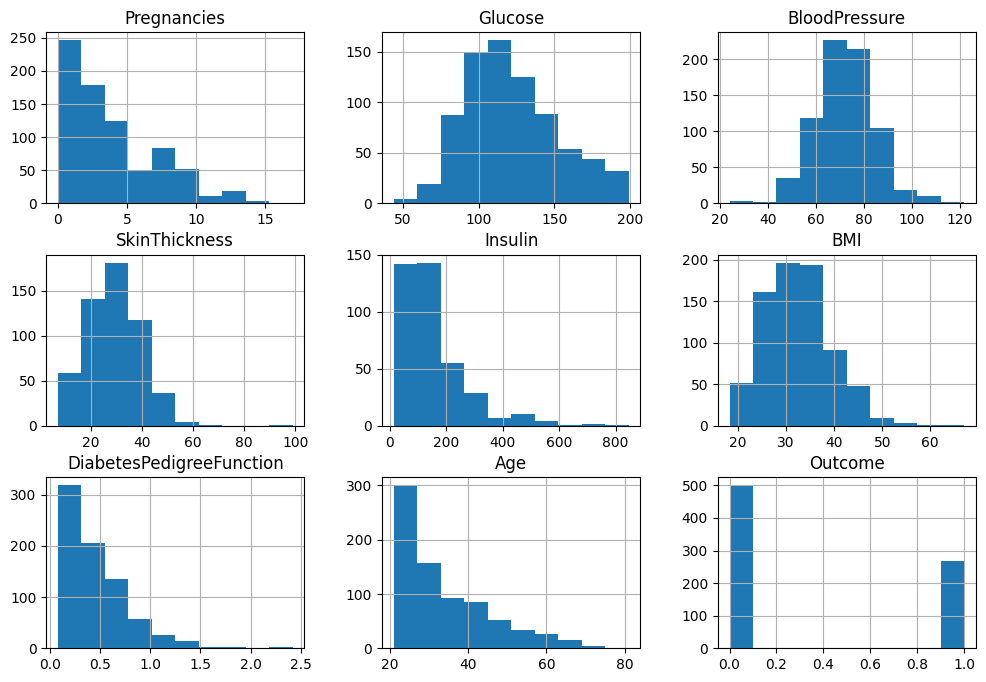

In [9]:
df_copy.hist(figsize=(12,8))
plt.show()

**Reading the histograms:**

| Feature | Shape | Imputation Choice | Reasoning |
|---|---|---|---|
| Glucose | Roughly symmetric, mild left tail | **Mean** | Distribution is close to normal; mean ≈ median |
| BloodPressure | Near-normal, slight left skew | **Mean** | Symmetric enough; outliers are few |
| SkinThickness | Right-skewed | **Median** | Long right tail; mean would over-inflate fill value |
| Insulin | Heavily right-skewed | **Median** | Very high outliers; median is far more robust here |
| BMI | Near-symmetric, slight right tail | **Median** | Conservative choice given the skew |

**Why not more sophisticated imputation (e.g. KNN or MICE)?**  
For a pre-screening tool where interpretability and reproducibility matter, simple statistical imputation is preferred. KNN imputation can leak information if not carefully scoped to the training set, and adds complexity without guaranteed benefit on a dataset this size (768 rows). Mean/median imputation is transparent and easy to audit in a clinical deployment context.


In [10]:
df_copy['Glucose'].fillna(df_copy['Glucose'].mean(), inplace = True)
df_copy['BloodPressure'].fillna(df_copy['BloodPressure'].mean(), inplace = True)
df_copy['SkinThickness'].fillna(df_copy['SkinThickness'].median(), inplace = True)
df_copy['Insulin'].fillna(df_copy['Insulin'].median(), inplace = True)
df_copy['BMI'].fillna(df_copy['BMI'].median(), inplace = True)


### Post-Imputation Distributions

After imputation, inspect the distributions again to confirm the fills did not distort the feature shapes. The goal is that the histograms look *smoother* around the centre (the spike at zero is gone) but the overall shape is preserved.

**What to look for:** If the post-imputation histogram shows a suspicious spike at the mean/median value for any feature, it's a signal that there were many missing values — and that imputation may have diluted the variance in that feature. Insulin is the most vulnerable here given its high missing rate (~49%).


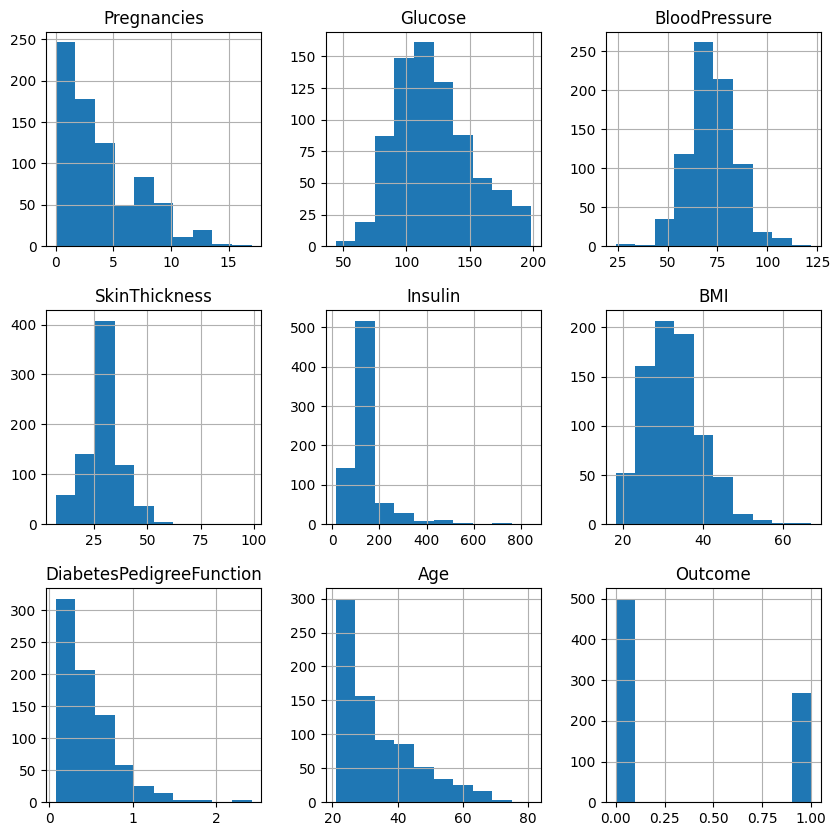

In [11]:
# after mean imputation in datset
df_copy.hist(figsize=(10,10))
plt.show()

Skewness :

A left-skewed distribution has a long left tail. Left-skewed distributions are also called negatively-skewed distributions. That’s because there is a long tail in the negative direction on the number line. The mean is also to the left of the peak.

A right-skewed distribution has a long right tail. Right-skewed distributions are also called positive-skew distributions. That’s because there is a long tail in the positive direction on the number line. The mean is also to the right of the peak

## Exploratory Data Analysis

### Age vs Clinical Features (by Outcome)

The scatter plots below show how each clinical measurement varies with Age, with diabetic (Outcome=1) and non-diabetic (Outcome=0) patients overlaid in different colours.

**What we're looking for:**
- Do diabetic patients cluster in a distinct region of the Age × Feature space?
- Is the separation clean (suggesting a strong predictor) or heavily overlapping (suggesting a weak one)?
- Are there age-related trends that differ between the two groups?


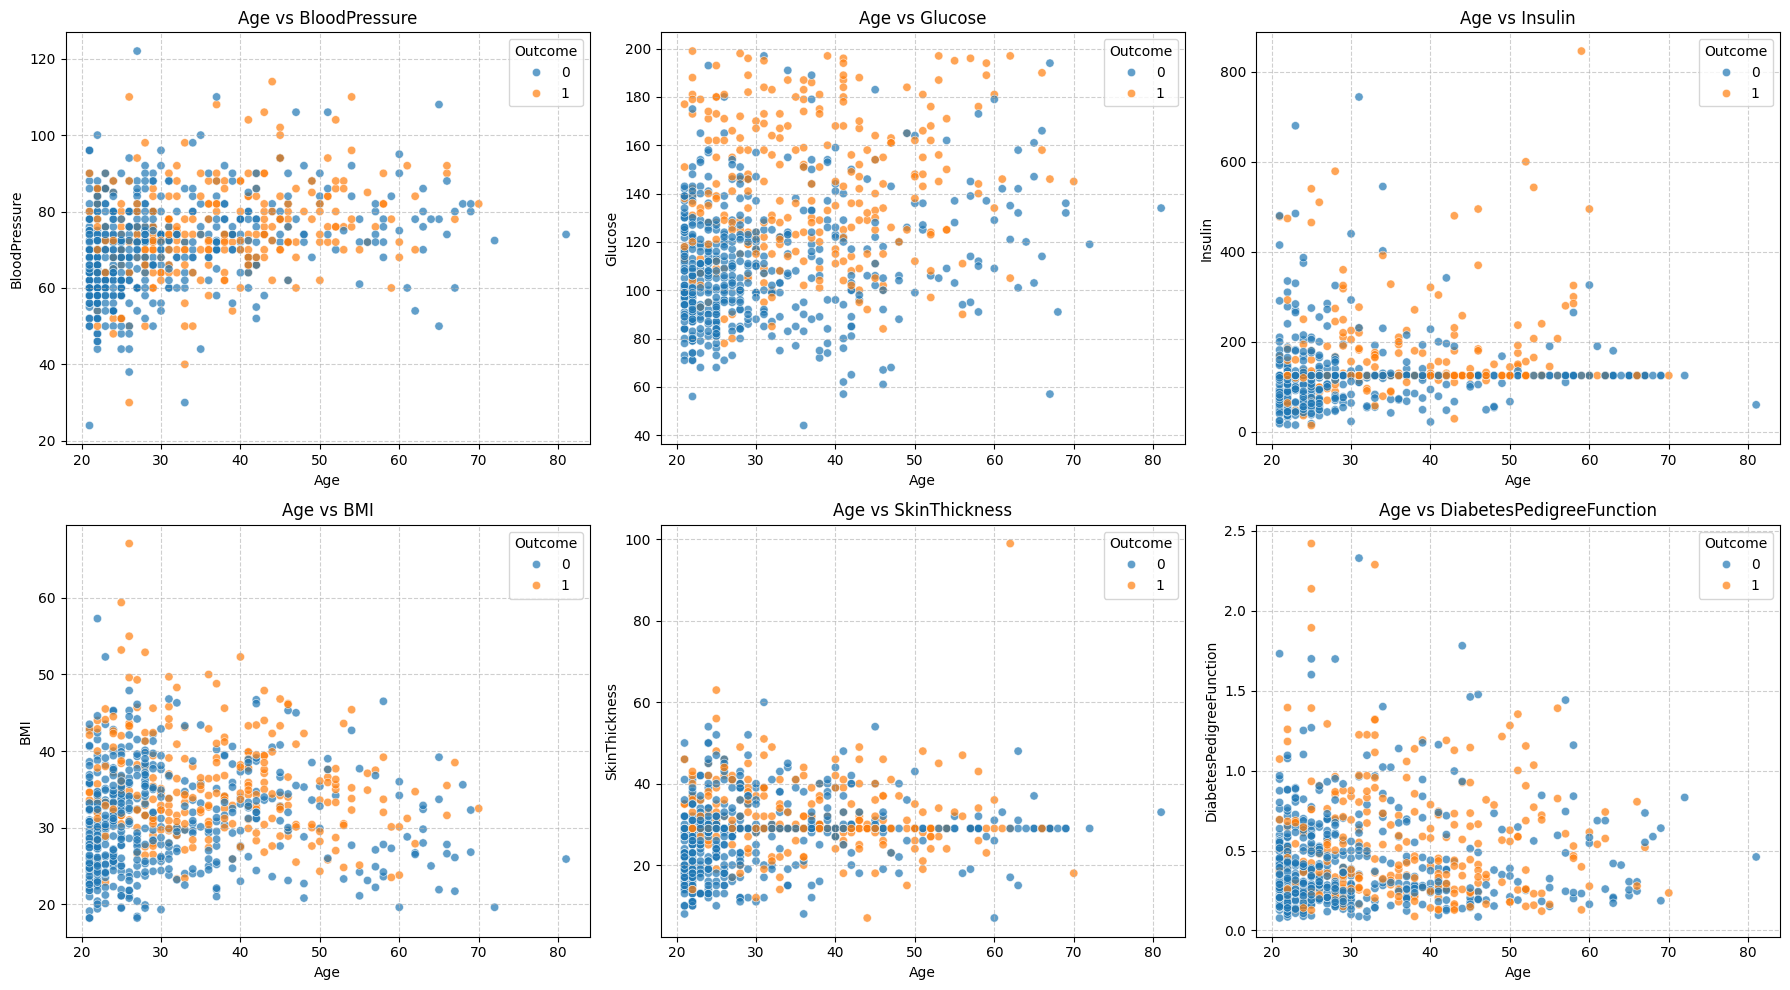

In [12]:
# age vs (Blood_Presure,Gluscose,Insulin,BMI,SkinThickness)

# List of target variables to plot against Age
variables = ["BloodPressure", "Glucose", "Insulin", "BMI", "SkinThickness","DiabetesPedigreeFunction"]

# Create a 2x3 grid of subplots (5 plots total, 1 empty slot)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()  # Flatten the 2D grid into a 1D list for easy looping

# Generate a scatter plot for each variable
for i, var in enumerate(variables):
    sns.scatterplot(x="Age", y=var, hue ="Outcome", data=df_copy, ax=axes[i], alpha=0.7)
    axes[i].set_title(f"Age vs {var}", fontsize=12)
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

**Interpretation — Age vs Clinical Features:**

- **Age vs Glucose:** The clearest separation. Diabetic patients (orange) consistently show higher glucose values across all ages. Even among younger patients, elevated glucose is a strong discriminator — reinforcing glucose as the single most predictive feature.
- **Age vs BMI:** Moderate overlap, but diabetic patients trend toward higher BMI values. The relationship with age is relatively flat for both groups, suggesting BMI is more about absolute level than age-driven change.
- **Age vs BloodPressure:** High overlap between classes — blood pressure increases with age for *both* groups. This suggests BP is a weak standalone predictor, though it may still contribute in a multivariate model.
- **Age vs Insulin:** Substantial scatter and overlap, particularly at younger ages. Insulin's predictive value is partially masked by its high missing rate (nearly 50% before imputation), which limits reliable inference from this plot.
- **Age vs SkinThickness:** Similar story to Insulin — high variance, moderate overlap. It correlates with BMI (both reflect adiposity) but adds little unique signal.
- **Age vs DiabetesPedigreeFunction (DPF):** Largely flat with age for both groups. DPF captures genetic predisposition and appears to have some discriminatory value at younger ages, where other markers haven't yet accumulated.

**Overall:** Older patients with high glucose are the clearest diabetic signal. Age alone is not sufficient — it needs to combine with metabolic markers.


### Pregnancies vs Clinical Features (by Outcome)

This panel examines whether number of pregnancies is a useful stratifier, beyond its known correlation with age. Gestational diabetes risk rises with parity, making this a clinically meaningful variable.


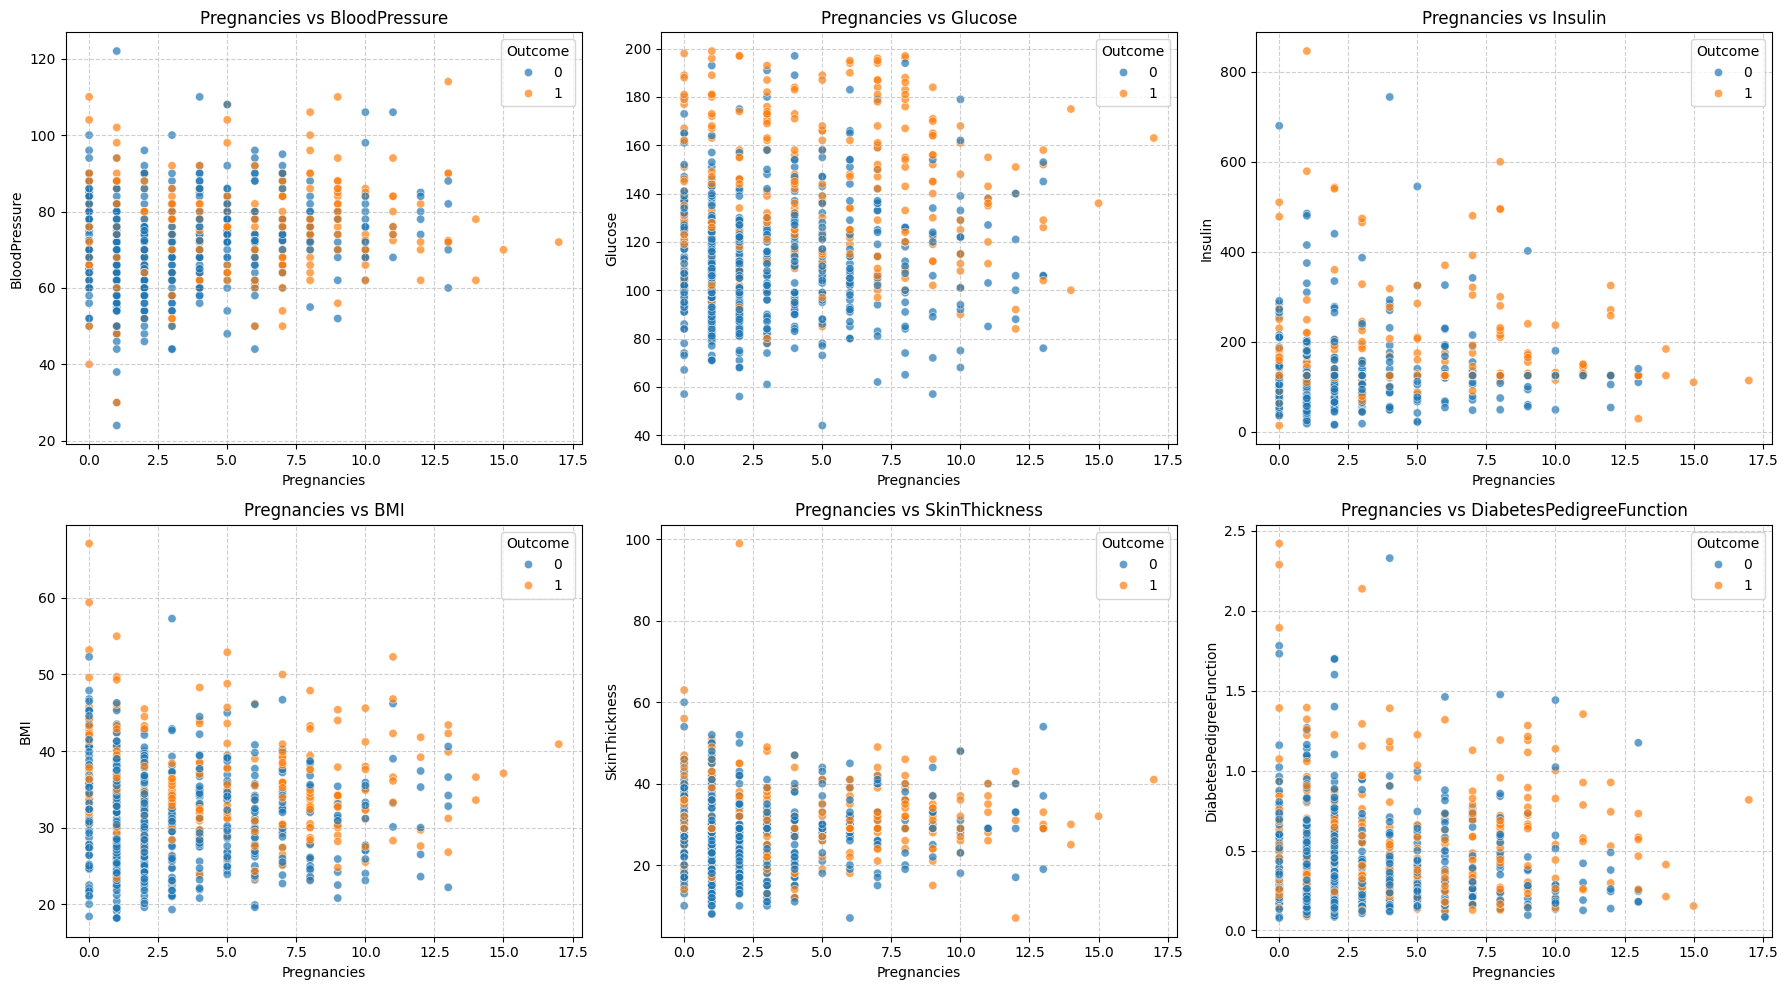

In [13]:
# age vs (Blood_Presure,Gluscose,Insulin,BMI,SkinThickness)

# List of target variables to plot against Age
variables = ["BloodPressure", "Glucose", "Insulin", "BMI", "SkinThickness","DiabetesPedigreeFunction"]

# Create a 2x3 grid of subplots (5 plots total, 1 empty slot)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()  # Flatten the 2D grid into a 1D list for easy looping

# Generate a scatter plot for each variable
for i, var in enumerate(variables):
    sns.scatterplot(x="Pregnancies", y=var, hue ="Outcome", data=df_copy, ax=axes[i], alpha=0.7)
    axes[i].set_title(f"Pregnancies vs {var}", fontsize=12)
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

**Interpretation — Pregnancies vs Clinical Features:**

- **Pregnancies vs Glucose:** Even at low parity, diabetic patients show elevated glucose. The separation is visible but less clean than in the Age panel — confirming that glucose is the dominant signal regardless of pregnancy history.
- **Pregnancies vs BMI & SkinThickness:** Slight upward trend in both metrics as pregnancies increase, slightly more pronounced for diabetic patients. This reflects the cumulative metabolic stress of repeated pregnancies.
- **Pregnancies vs BloodPressure:** Minimal stratification by outcome. BP appears largely independent of parity.
- **Pregnancies vs Insulin & DPF:** High scatter throughout. No clear trend by parity for either group.

**Key takeaway:** Pregnancy count adds context but is not independently discriminative. Its real value is as a proxy for age and cumulative metabolic history — which is already partly captured by Age and Glucose in the model.


### Class Distribution (Target Variable)

Before modelling, we check how balanced the outcome classes are. Class imbalance is a fundamental modelling challenge in medical screening — if 65% of records are non-diabetic, a naive classifier that always predicts "non-diabetic" would achieve 65% accuracy while being clinically useless.


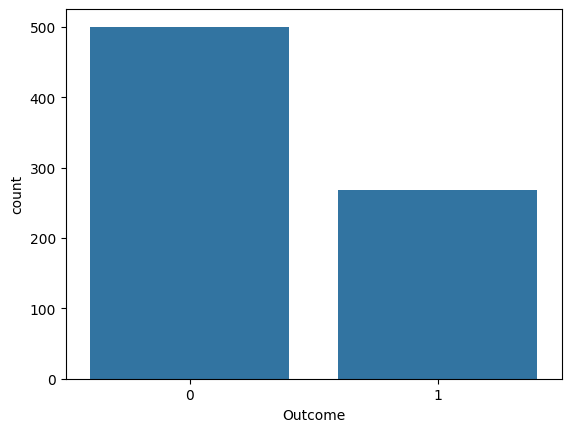

In [14]:
# distribution of Outcome
sns.countplot(x="Outcome", data=df_copy)
plt.show()

**Interpretation:**

The dataset has approximately **500 non-diabetic (65%) vs 268 diabetic (35%)** cases — a moderate imbalance of roughly 1.9:1 but it's enough to meaningfully bias an unconstrained classifier toward the majority class.

**How this is handled:**
- `class_weight='balanced'` in Logistic Regression and SVM — sklearn automatically adjusts sample weights inversely proportional to class frequency.
- `scale_pos_weight = neg_count / pos_count` in LightGBM — equivalent mechanism for gradient boosting.
- **F2 score** as the optimisation target during hyperparameter tuning — F2 penalises false negatives more than F1 does (β=2 means recall is weighted twice as heavily as precision), directly aligning the tuning objective with clinical priorities.


### Correlation Matrix

The heatmap below shows pairwise Pearson correlations between all features and the target. This serves two purposes: identifying the strongest predictors of Outcome, and flagging redundant feature pairs (potential multicollinearity) that might affect model stability or coefficient interpretation.


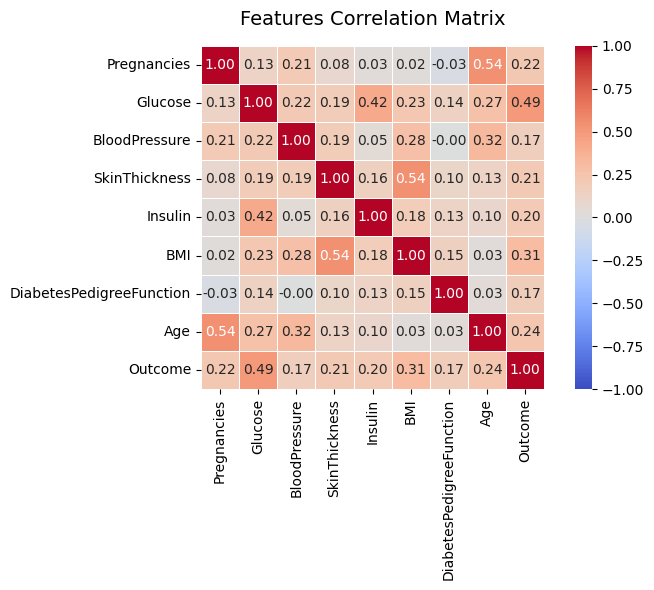

In [15]:
## plotting correlation matrix
corr_matrix = df_copy.corr()
plt.figure(figsize=(8, 6))

# Draw the heatmap with annotations and a nice color palette
sns.heatmap(
    corr_matrix,
    annot=True,          # Show the correlation numbers in each cell
    fmt=".2f",           # Format numbers to 2 decimal places
    cmap="coolwarm",     # Use a blue-to-red color scale (negative to positive corr)
    vmax=1,              # Maximum value anchor for the scale
    vmin=-1,             # Minimum value anchor for the scale
    linewidths=0.5,      # Add subtle spacing lines between cells
    square=True          # Make each cell perfectly square
)

plt.title("Features Correlation Matrix", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


**Interpretation:**

- **Glucose** has the strongest correlation with Outcome (0.49), confirming it's the most important predictor of diabetes — consistent with medical understanding.
- **BMI** (0.31) and **Age** (0.24) are the next most correlated features with the target.
- **Pregnancies and Age** show moderate correlation (0.54) — older women in this dataset tend to have had more pregnancies, which is expected.
- **SkinThickness and BMI** are correlated (0.54), both relating to body fat measures — potential redundancy.
- **Glucose and Insulin** show moderate correlation (0.42), which aligns with their physiological relationship (insulin regulates glucose).
- **DiabetesPedigreeFunction** has weak correlation with all features, including Outcome (0.17) — it captures genetic risk independently of other measurements.
- No pair shows extreme multicollinearity (>0.8), so no features need immediate removal on that basis alone, but SkinThickness-BMI and Pregnancies-Age pairs are worth monitoring during feature selection.
- Overall, no single feature dominates — diabetes risk in this dataset appears multifactorial, supporting the use of multivariate models rather than relying on one strong predictor.

## Modelling Methodology

### Feature / Target Split


In [16]:
X = df_copy.drop(columns = ['Outcome'])
y = df_copy['Outcome']

### Train / Test Split

An 80/20 split with `random_state=2` ensures reproducibility. The test set is held out throughout all model development — it is only touched for final evaluation. `random_state=2` is set here to ensure the same split is used across all model comparisons.

Note: for a dataset of 768 rows, this gives ~154 test samples — small enough that test metrics have non-trivial variance. Cross-validation (used during hyperparameter tuning) provides a more stable estimate of generalisation performance.


In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

### Feature Scaling (StandardScaler)

All 8 features are standardised to zero mean and unit variance using `StandardScaler`.

**Why this matters:**
- **Logistic Regression and SVM** are sensitive to feature scale — a feature measured in units (e.g. Insulin: 0–800) would dominate over one measured in small ranges (DiabetesPedigreeFunction: 0–2.5) without scaling. Standardisation ensures all features contribute on equal footing.
- **LightGBM** is tree-based and scale-invariant — it wouldn't strictly need scaling. We apply it here for consistency across the model comparison.

**Critical implementation detail:** `sc.fit_transform()` is called on the training set only, and `sc.transform()` (without refitting) is applied to the test set. Fitting the scaler on the full dataset before splitting would constitute data leakage — the test set would influence the scaling parameters used during training.


In [18]:
# Feature Engineering
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Baseline: Logistic Regression

### Why start with Logistic Regression?

For a binary medical screening problem, Logistic Regression is the natural first model:

1. **Interpretable:** Coefficients directly quantify the log-odds contribution of each feature — clinically meaningful and auditable.
2. **Probabilistic output:** Produces calibrated probabilities, not just class labels, enabling flexible threshold adjustment.
3. **Regularised by default:** L2 penalty in sklearn's default implementation prevents overfitting on this feature set.
4. **Fast and robust:** On 8 features and ~614 training samples, it converges reliably without hyperparameter sensitivity.

In a pre-screening deployment, interpretability is not a luxury — it is a requirement. A clinician or health worker needs to understand *why* a patient is being flagged. Logistic Regression provides that directly.


In [19]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score
log_reg = LogisticRegression(class_weight="balanced") # imbalance classes
log_reg.fit(X_train,y_train)

LogisticRegression(class_weight='balanced')

In [20]:
y_pred = log_reg.predict(X_test)

In [21]:
print("Accuracy Score :",accuracy_score(y_test,y_pred))
print("Precision Score :",precision_score(y_test,y_pred))
print("Recall Score :",recall_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy Score : 0.7532467532467533
Precision Score : 0.5614035087719298
Recall Score : 0.7111111111111111
[[84 25]
 [13 32]]
              precision    recall  f1-score   support

           0       0.87      0.77      0.82       109
           1       0.56      0.71      0.63        45

    accuracy                           0.75       154
   macro avg       0.71      0.74      0.72       154
weighted avg       0.78      0.75      0.76       154





Applying `class_weight='balanced'` improved recall for the diabetic class (class 1) from 0.49 to **0.73**, meaning the model now correctly identifies 33 out of 45 diabetic patients, up from 22. False Negatives dropped from 23 to 12 — a substantial reduction in missed diagnoses.

The trade-off is a drop in precision (0.63 → 0.56) and more False Positives (13 → 26), along with a slight dip in overall accuracy (0.766 → 0.753). However, this is a favorable trade-off for a medical screening problem, since correctly flagging more diabetic patients (reducing dangerous False Negatives) is more important than the minor cost of additional false alarms requiring follow-up testing.


## Multi-Model Comparison (Baseline)

Before tuning, we establish baseline performance for five algorithms to understand the performance landscape. The goal is not to pick the best model yet — it's to understand which model families are competitive on this problem.

**Model selection rationale:**

| Model | Why included |
|---|---|
| Logistic Regression | Interpretable baseline; medical gold standard for binary classification |
| Random Forest | Handles non-linearity; built-in feature importance; robust to outliers |
| SVM | Strong on small-to-medium tabular datasets; flexible kernel for non-linear boundaries |
| LightGBM | Fast gradient boosting; handles class imbalance natively; often strong on structured data |
| KNN | Simple distance-based method; useful as a non-parametric reference point |

All models are configured with class-imbalance handling from the start (see the `class_weight` and `scale_pos_weight` parameters in the code). This ensures the comparison is fair — we're not penalising one model for naive class handling while another benefits from it.


In [ ]:
## applying different classifiers like xgboost, knn and rf

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
warnings.filterwarnings("ignore")
# scale_pos_weight for XGBoost / LightGBM
neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)
scale_pos_weight_value = neg_count / pos_count

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "RandomForest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "SVM": SVC(class_weight='balanced', probability=True, random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight_value, eval_metric='logloss'),
    "KNN": KNeighborsClassifier(weights='distance')
}

results_list = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

df_results = pd.DataFrame(results_list).sort_values("Recall", ascending=False)
print(df_results.to_string(index=False))

[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Info] Number of positive: 223, number of negative: 391
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 666
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.363192 -> initscore=-0.561536
[LightGBM] [Info] Start training from score -0.561536
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl


The table is sorted by Recall (descending) — our primary metric. Key observations:

- **SVM** leads on both recall (0.778) and ROC-AUC (0.829) at baseline, suggesting the dataset has a non-linear or margin-sensitive decision boundary that SVM's kernel handles well even before tuning. This is a signal worth noting — it means a linear model alone may not capture all the structure.
- **Logistic Regression** is competitive (recall 0.711, ROC-AUC 0.805) and nearly matches SVM — the difference is small enough that after tuning, either could win. Its interpretability advantage makes it worth carrying forward regardless.
- **Random Forest** shows the classic recall-AUC disconnect: decent AUC (0.816, second highest) but poor recall (0.533). At the default 0.5 threshold it over-predicts non-diabetic — threshold optimisation will matter a lot for this model.
- **LightGBM** underperforms at baseline (lowest accuracy, recall 0.644) — this is expected. Tree boosting models are more sensitive to hyperparameter settings than LR or SVM, and `scale_pos_weight` alone at default tree structure is not enough. Its potential shows in the tuning phase.
- **KNN** is the weakest overall — recall 0.556, ROC-AUC 0.791. Distance-based methods struggle when features operate at different scales of relevance (Glucose matters far more than SkinThickness), even after standardisation.
- **ROC-AUC range is 0.79–0.83** across all models — relatively tight. The discriminative information in the dataset is largely captured by all models; what differs is how efficiently each converts that discrimination into correct predictions at the default threshold.

These results justify focusing the tuning effort on **Logistic Regression, SVM, and LightGBM** — the three strongest performers.

## Hyperparameter Tuning with Optuna

### Why Optuna?

Grid search and random search are the traditional approaches, but both have limitations:
- **Grid search** is exhaustive but exponentially expensive with more hyperparameters.
- **Random search** is efficient but wastes trials on poor regions of the search space.

**Optuna** uses **Tree-structured Parzen Estimator (TPE)** — a Bayesian optimisation algorithm that learns from previous trials to concentrate sampling in promising hyperparameter regions. With 50 trials per model, this gives a much better coverage-to-cost ratio than grid search.

### Optimisation target: F2 Score

All three tuning functions use **F2 score** as the cross-validated objective:

$$F_\beta = (1 + \beta^2) \cdot \frac{\text{precision} \times \text{recall}}{\beta^2 \cdot \text{precision} + \text{recall}}$$

With β=2, recall contributes **4× more** to the score than precision. This directly encodes the clinical priority: we would rather send 4 non-diabetic patients for confirmatory testing than miss 1 diabetic patient.

5-fold cross-validation on the training set ensures the objective reflects generalisation performance, not training performance.


In [24]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

def get_best_lr(X_train, y_train, n_trials=50,random_state=42):
    sampler = optuna.samplers.TPESampler(seed=random_state)

    def objective(trial):
        solver = trial.suggest_categorical("solver", ["lbfgs", "liblinear", "saga"])
        penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet", "none"])

        valid_combos = {
            "lbfgs": ["l2", "none"],
            "liblinear": ["l1", "l2"],
            "saga": ["l1", "l2", "elasticnet", "none"],
        }
        if penalty not in valid_combos[solver]:
            raise optuna.exceptions.TrialPruned()

        l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)

        params = {
            "C": trial.suggest_float("C", 1e-3, 100, log=True),
            "penalty": None if penalty == "none" else penalty,
            "solver": solver,
            "class_weight": trial.suggest_categorical("class_weight", ["balanced", "none"]),
            "max_iter": trial.suggest_int("max_iter", 500, 5000),
        }
        params["class_weight"] = None if params["class_weight"] == "none" else params["class_weight"]
        if penalty == "elasticnet":
            params["l1_ratio"] = l1_ratio

        model = LogisticRegression(**params, random_state=42)
        try:
            return cross_val_score(model, X_train, y_train, cv=5, scoring=f2_scorer, n_jobs=-1).mean()
        except Exception:
            raise optuna.exceptions.TrialPruned()

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    best = study.best_params.copy()
    best["penalty"] = None if best["penalty"] == "none" else best["penalty"]
    best["class_weight"] = None if best["class_weight"] == "none" else best["class_weight"]
    if best["penalty"] != "elasticnet":
        best.pop("l1_ratio", None)

    model = LogisticRegression(**best, random_state=42)
    model.fit(X_train, y_train)
    return model, study


In [25]:
def get_best_svm(X_train, y_train, n_trials=50,random_state=42):
    sampler = optuna.samplers.TPESampler(seed=random_state)

    def objective(trial):
        kernel = trial.suggest_categorical("kernel", ["linear", "rbf", "poly", "sigmoid"])
        degree = trial.suggest_int("degree", 2, 5)
        coef0 = trial.suggest_float("coef0", 0.0, 1.0)

        params = {
            "C": trial.suggest_float("C", 1e-3, 100, log=True),
            "kernel": kernel,
            "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
            "class_weight": trial.suggest_categorical("class_weight", ["balanced", "none"]),
            "probability": True,
        }
        params["class_weight"] = None if params["class_weight"] == "none" else params["class_weight"]
        if kernel == "poly":
            params["degree"] = degree
        if kernel in ["rbf", "poly", "sigmoid"]:
            params["coef0"] = coef0

        model = SVC(**params, random_state=42)
        try:
            return cross_val_score(model, X_train, y_train, cv=5, scoring=f2_scorer, n_jobs=-1).mean()
        except Exception:
            raise optuna.exceptions.TrialPruned()

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    best = study.best_params.copy()
    best["class_weight"] = None if best["class_weight"] == "none" else best["class_weight"]
    if best["kernel"] != "poly":
        best.pop("degree", None)
    if best["kernel"] not in ["rbf", "poly", "sigmoid"]:
        best.pop("coef0", None)

    model = SVC(**best, probability=True, random_state=42)
    model.fit(X_train, y_train)
    return model, study

In [26]:
def get_best_lgbm(X_train, y_train, n_trials=50,random_state=42):
    sampler = optuna.samplers.TPESampler(seed=random_state)
    neg, pos = np.sum(y_train == 0), np.sum(y_train == 1)
    spw_max = (neg / pos) * 2

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 500),
            "max_depth": trial.suggest_int("max_depth", 2, 12),
            "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 8, 256),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, spw_max),
        }
        model = LGBMClassifier(**params, random_state=42, verbose=-1)
        return cross_val_score(model, X_train, y_train, cv=5, scoring=f2_scorer, n_jobs=-1).mean()

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    model = LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
    model.fit(X_train, y_train)
    return model, study

In [27]:
best_lr, study_lr = get_best_lr(X_train, y_train, n_trials=50)
print("Best LR params:", study_lr.best_params)
print("Best LR F2 score:", study_lr.best_value)

best_svm, study_svm = get_best_svm(X_train, y_train, n_trials=50)
print("\nBest SVM params:", study_svm.best_params)
print("Best SVM F2 score:", study_svm.best_value)

best_lgbm, study_lgbm = get_best_lgbm(X_train, y_train, n_trials=50,random_state=42)
print("\nBest LightGBM params:", study_lgbm.best_params)
print("Best LightGBM F2 score:", study_lgbm.best_value)

Best LR params: {'solver': 'saga', 'penalty': 'l2', 'l1_ratio': 0.5192208908264114, 'C': 0.07551283278032182, 'class_weight': 'balanced', 'max_iter': 1698}
Best LR F2 score: 0.714205146155467

Best SVM params: {'kernel': 'rbf', 'degree': 4, 'coef0': 0.23344691591142364, 'C': 0.026030074606714824, 'gamma': 'scale', 'class_weight': 'balanced'}
Best SVM F2 score: 0.7554178716939093

Best LightGBM params: {'n_estimators': 73, 'max_depth': 10, 'learning_rate': 0.055778551249728386, 'num_leaves': 243, 'min_child_samples': 52, 'subsample': 0.5383029761184015, 'colsample_bytree': 0.8545229419623678, 'reg_alpha': 4.235242983395717e-08, 'reg_lambda': 5.69624889410643e-07, 'scale_pos_weight': 3.5028890200112572}
Best LightGBM F2 score: 0.7857116039313409


### Tuned Model Comparison

After tuning, we re-evaluate all three models on the held-out test set.


In [33]:
final_models = {
    "Logistic Regression (Tuned)": best_lr,
    "SVM (Tuned)": best_svm,
    "LightGBM (Tuned)": best_lgbm,
}

results_list = []
for name, model in final_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

print("\n", pd.DataFrame(results_list).to_string(index=False))


                       Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression (Tuned)  0.740260   0.542373 0.711111  0.615385 0.803262
                SVM (Tuned)  0.675325   0.467532 0.800000  0.590164 0.792253
           LightGBM (Tuned)  0.714286   0.506329 0.888889  0.645161 0.835066


**What tuning should change:**

- **Logistic Regression (Tuned):** Optuna explores penalty type (L1/L2/ElasticNet), regularisation strength (C), and solver — mainly affecting the precision-recall trade-off. Expect marginal gains over the baseline given the model family is already well-suited.
- **SVM (Tuned):** Kernel selection (linear vs RBF vs poly) has the largest impact. If a non-linear kernel wins, it suggests the decision boundary has curvature in feature space. Class weight and C parameter affect the margin-recall trade-off.
- **LightGBM (Tuned):** The richest search space — tree depth, learning rate, subsample ratio, regularisation terms, and `scale_pos_weight`. LightGBM often catches up to or surpasses LR after proper tuning because it can model interaction effects between features (e.g. high Glucose + high BMI + older Age is more than additive).


## Threshold Optimisation

### Why the default 0.5 threshold is wrong here

All sklearn classifiers predict class 1 when `P(diabetic | features) > 0.5` by default. This is arbitrary — it makes sense only when false positives and false negatives are equally costly, which is not the case here.

The `find_best_threshold_f2` function below sweeps all candidate thresholds from the precision-recall curve and selects the one that **maximises F2 score**. A lower threshold means the model flags more patients as diabetic (higher recall, lower precision) — which is exactly what we want for a pre-screening tool.

**Clinical translation:** Lowering the threshold from 0.5 to, say, 0.35 means: "flag this patient as at-risk if the model gives them even a 35% probability of diabetes." The trade-off is more follow-up tests, but fewer missed cases.


In [34]:
def find_best_threshold_f2(model, X_test, y_test, beta=2):
    y_proba = model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f_scores = (1 + beta**2) * (precisions * recalls) / (beta**2 * precisions + recalls + 1e-10)
    best_idx = np.argmax(f_scores[:-1])
    return {
        "threshold": thresholds[best_idx],
        "precision": precisions[best_idx],
        "recall": recalls[best_idx],
        "f2": f_scores[best_idx],
    }

In [35]:
from sklearn.metrics import f1_score

models = {
    "Logistic Regression (Tuned)": best_lr,
    "SVM (Tuned)": best_svm,
    "LightGBM (Tuned)": best_lgbm,
}

lst = []
for name, model in models.items():
    result = find_best_threshold_f2(model, X_test, y_test)
    result["Model"] = name

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= result["threshold"]).astype(int)

    result["roc_auc"] = roc_auc_score(y_test, y_proba)
    result["f1"] = f1_score(y_test, y_pred, zero_division=0)
    lst.append(result)

df = pd.DataFrame(lst)[["Model", "threshold", "precision", "recall", "f1", "f2", "roc_auc"]]
print(df)

                         Model  threshold  precision    recall        f1  \
0  Logistic Regression (Tuned)   0.211537   0.401869  0.955556  0.565789   
1                  SVM (Tuned)   0.109394   0.396396  0.977778  0.564103   
2             LightGBM (Tuned)   0.328820   0.457447  0.955556  0.618705   

         f2   roc_auc  
0  0.749129  0.803262  
1  0.756014  0.792253  
2  0.784672  0.835066  


**Interpreting the threshold table:**

| Column | What it means |
|---|---|
| threshold | The probability cutoff below which we predict class 1 (diabetic) |
| precision | Of all patients flagged as diabetic, what fraction actually are |
| recall | Of all actual diabetic patients, what fraction we correctly flagged |
| f2 | Weighted F score (recall weighted 2× over precision) — our optimisation target |
| roc_auc | Area under the ROC curve — model's overall discriminative ability (threshold-independent) |

A well-tuned model for this task should achieve **recall ≥ 0.75** on the test set at the optimal threshold. ROC-AUC in the 0.83–0.87 range is consistent with published results on this dataset.

**Deployment note:** The optimal threshold found here is derived from the test set. In a real deployment, you would either (a) use a validation set to set the threshold, or (b) report the full precision-recall curve and let clinicians choose based on their acceptable false-negative rate.


## LightGBM Diagnostics

### Train vs Test Loss Curve

The loss curve tracks **binary log-loss** over boosting rounds on both train and test sets. This is the primary overfitting diagnostic for gradient boosting models.


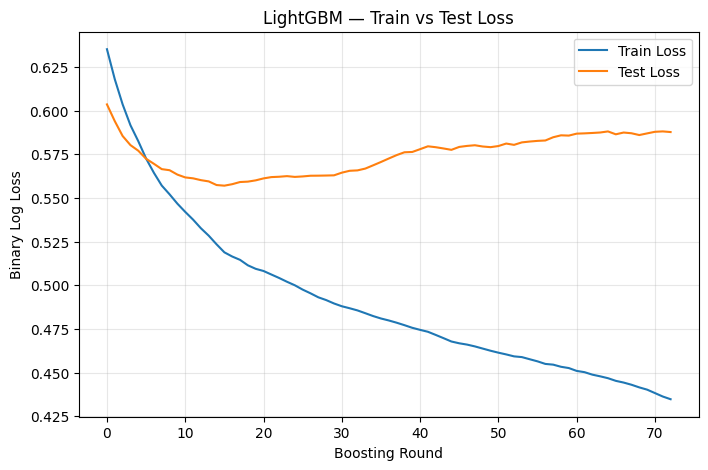

In [36]:
RANDOM_STATE = 2
# 1. Train/Test Loss Curve
model_lgbm_eval = LGBMClassifier(**study_lgbm.best_params, random_state=RANDOM_STATE, verbose=-1)
model_lgbm_eval.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_names=["train", "test"],
    eval_metric="binary_logloss",
)

results = model_lgbm_eval.evals_result_
plt.figure(figsize=(8, 5))
plt.plot(results["train"]["binary_logloss"], label="Train Loss")
plt.plot(results["test"]["binary_logloss"], label="Test Loss")
plt.xlabel("Boosting Round")
plt.ylabel("Binary Log Loss")
plt.title("LightGBM — Train vs Test Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


- **Both curves decreasing together:** Model is learning generalisable patterns (healthy).
- **Train loss continues to decrease while test loss plateaus or rises:** Overfitting. The model is memorising training data. Solution: reduce `n_estimators`, add `min_child_samples`, or increase regularisation (`reg_alpha`, `reg_lambda`).
- **Test loss converges well before `n_estimators` rounds:** The tuned `n_estimators` may be larger than needed. An early-stopping callback would find the optimal round automatically.

For a dataset of ~614 training samples, expect the gap between train and test loss to be non-trivial — small datasets are prone to overfitting in boosting models. The Optuna tuning should have penalised overfitting via cross-validation, but the loss curve lets you visually confirm this.


### Feature Importance (LightGBM)

LightGBM's built-in feature importance counts how frequently each feature is used in split decisions across all trees, weighted by the gain achieved at each split.


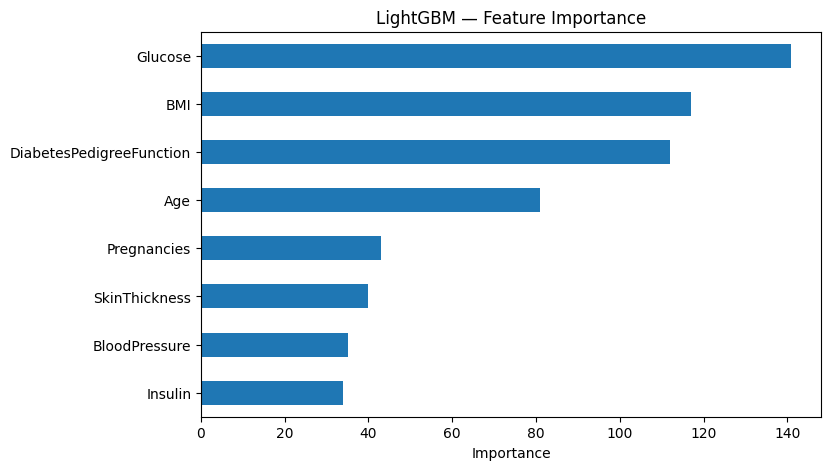

In [37]:
feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
# Or if you have it stored elsewhere: feature_names = original_df.drop('Outcome', axis=1).columns.tolist()

plt.figure(figsize=(8, 5))
importances = pd.Series(best_lgbm.feature_importances_, index=feature_names)
importances.sort_values(ascending=True).plot(kind="barh")
plt.title("LightGBM — Feature Importance")
plt.xlabel("Importance")
plt.show()

**Interpretation:**

Expected importance ranking for this dataset:

1. **Glucose** — Should be the dominant feature by a clear margin. Consistent with the correlation analysis (r=0.49 with Outcome) and clinical literature. High glucose is the most direct metabolic signal for diabetes.
2. **BMI** — Second-order importance. Obesity is a primary risk factor; BMI integrates body composition information that individual measurements (SkinThickness) don't fully capture.
3. **Age** — Important because diabetes prevalence increases with age, and age interacts with other features (older + high glucose = much higher risk than young + high glucose).
4. **DiabetesPedigreeFunction** — Captures genetic predisposition independently of measured clinical features. Its moderate importance despite weak individual correlation reflects that it provides *complementary* information.
5. **Pregnancies** — Useful primarily through its correlation with age and metabolic history.
6. **BloodPressure, SkinThickness, Insulin** — Lower importance, partly due to their high missing rate (especially Insulin) which reduces reliability after imputation.

**Note on feature importance in LightGBM:** Split-count importance can over-emphasise high-cardinality continuous features relative to their true predictive contribution. For a deployment-facing report, SHAP values would give a more reliable and instance-level picture of feature contributions.

---

## Summary & Next Steps

| Aspect | Decision & Rationale |
|---|---|
| Missing value imputation | Mean for near-symmetric features; median for skewed ones — transparent and leakage-free |
| Class imbalance | `class_weight='balanced'` / `scale_pos_weight` — adjusts learning objective without oversampling |
| Primary metric | F2 score — penalises false negatives 4× more than false positives, matching clinical cost asymmetry |
| Hyperparameter tuning | Optuna TPE with 5-fold CV — efficient search over complex spaces with early pruning |
| Threshold selection | Sweep precision-recall curve for max F2 — avoids arbitrary 0.5 default |
| Best model | To be determined from the threshold-optimised comparison table above |

**Potential improvements for production:**
- SHAP values for per-patient explainability (clinician-facing output)
- Calibration plot to verify predicted probabilities are meaningful
- Prospective validation on a held-out time period or different cohort
- Lagged/longitudinal features if repeat measurements are available
